# Overfitting vs Underfitting Project

Welcome to the part of machine learning where models stop looking like math formulas and start looking like characters in a story.

Some models are too cautious. They look at a complicated world and draw a straight line through it. They miss the shape of reality.

Some models are too eager. They memorize every wrinkle in the training data, every lucky accident, every tiny bit of noise. They look brilliant in rehearsal and fall apart on opening night.

This project is about that failure mode.

> A model can memorize... or it can generalize. Great ML lives in the balance.

GraphX Labs theme: we are not just asking which model scores higher. We are asking whether the model learned something that survives contact with new data.

## 1. Problem Statement

Predictive models fail quietly.

They do not usually announce, "I memorized the training data." They give us a clean metric, a confident prediction, maybe even a beautiful accuracy score. Then production arrives. New patients. New customers. New behavior. The world shifts slightly, and the model that looked smart suddenly becomes brittle.

In this project, we investigate a healthcare classification problem and watch different models fail in different ways:

- underfitting: the model is too simple to learn the real signal
- overfitting: the model is flexible enough to memorize noise
- good fit: the model captures meaningful structure without chasing every accident

The real goal is generalization: performance on data the model has never seen.

## 2. The Core Question

The central question is not:

> How high is the training accuracy?

The central question is:

> Did the model actually learn patterns... or did it just memorize the training data?

Imagine two students.

One student memorizes the answer key. On the practice test, they look unstoppable. Change the questions slightly, and the performance collapses.

The other student understands the ideas. They may not remember every exact question, but they can handle new versions because they learned the structure underneath.

Machine learning models behave the same way. Training data is the practice exam. Test data is the first hint of the real world. Production data is the exam nobody gave you in advance.

The model's job is not to remember the past perfectly. It is to learn enough from the past to survive the future.

## 3. Dataset Overview

Dataset source: scikit-learn Breast Cancer Wisconsin diagnostic dataset.

This is a realistic healthcare classification dataset built from measurements of cell nuclei in digitized breast mass images.

Business interpretation:

- Each row describes one medical case.
- Each feature captures a measured property such as radius, texture, smoothness, concavity, or symmetry.
- The target tells us whether the tumor is benign or malignant.

Target variable used in this project:

- `is_benign = 1`: benign
- `is_benign = 0`: malignant

Why this dataset works for this project:

- It has enough features for models to become too flexible.
- It is small enough that overfitting is easy to demonstrate.
- It supports regularization, tree-depth control, cross-validation, learning curves, and train/test comparison.

## 4. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from src.preprocessing.data_preprocessing import TARGET_COLUMN, make_train_test_split, save_raw_and_processed
from src.models.model_factory import underfit_tree, balanced_tree, overfit_tree, regularized_logistic
from src.evaluation.metrics import evaluate_many, cross_validation_table
from src.experiments.complexity import decision_tree_complexity_curve
from src.visualization.plots import plot_train_test_bars, plot_complexity_curve, plot_learning_curves

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 5. Load Dataset

We save both a raw and processed copy. The processed version is intentionally light because this dataset is already clean. The point of this project is not data cleaning drama; it is model behavior.

In [2]:
raw_path = PROJECT_ROOT / "data/raw/breast_cancer_wisconsin.csv"
processed_path = PROJECT_ROOT / "data/processed/breast_cancer_wisconsin_processed.csv"

df = save_raw_and_processed(raw_path, processed_path)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,is_benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 6. Initial Data Inspection

Before we let models speak, we inspect the room they are walking into: shape, missing values, column types, and target distribution.

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head())
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("proportion"))
df.describe().T.head(10)

Shape: (569, 31)

Missing values:
mean radius                0
concavity error            0
worst fractal dimension    0
worst symmetry             0
worst concave points       0
dtype: int64

Target distribution:
1    0.627417
0    0.372583
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 7. Exploratory Data Analysis

The dataset contains medical measurements that are not random noise. Some features separate malignant and benign cases clearly, while others overlap. That overlap is where model quality gets interesting: the model must learn signal without hallucinating certainty.

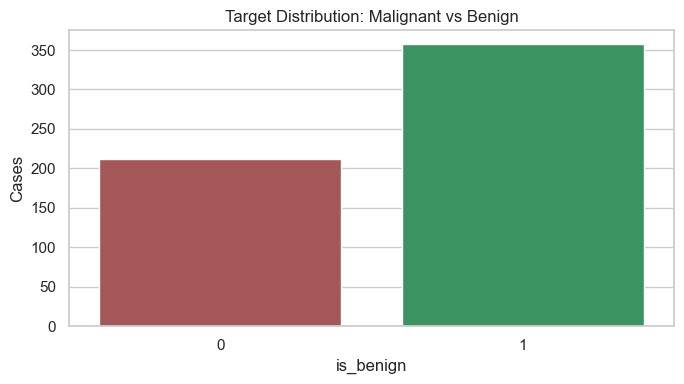

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COLUMN, palette=["#b04a4a", "#2ca25f"])
plt.title("Target Distribution: Malignant vs Benign")
plt.xlabel("is_benign")
plt.ylabel("Cases")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

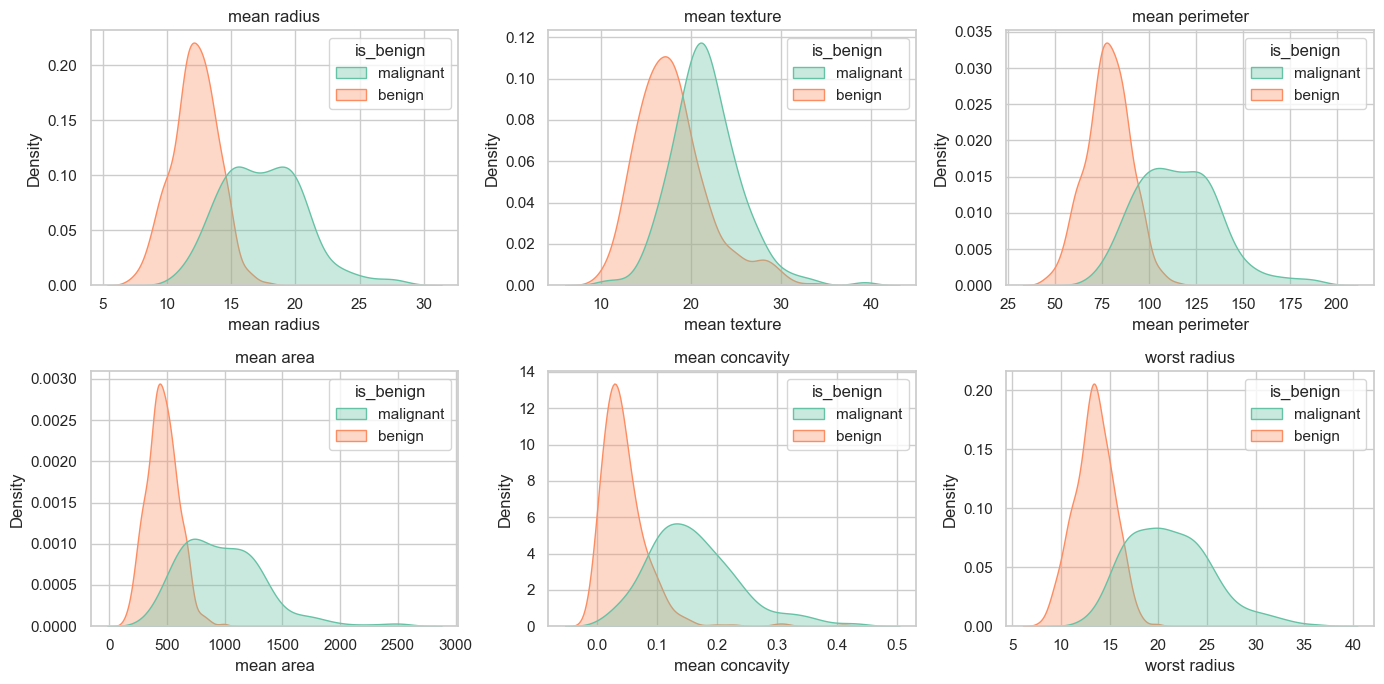

In [5]:
important_features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean concavity", "worst radius"]
plot_df = df[important_features + [TARGET_COLUMN]].copy()
plot_df[TARGET_COLUMN] = plot_df[TARGET_COLUMN].map({0: "malignant", 1: "benign"})

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), important_features):
    sns.kdeplot(data=plot_df, x=col, hue=TARGET_COLUMN, fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

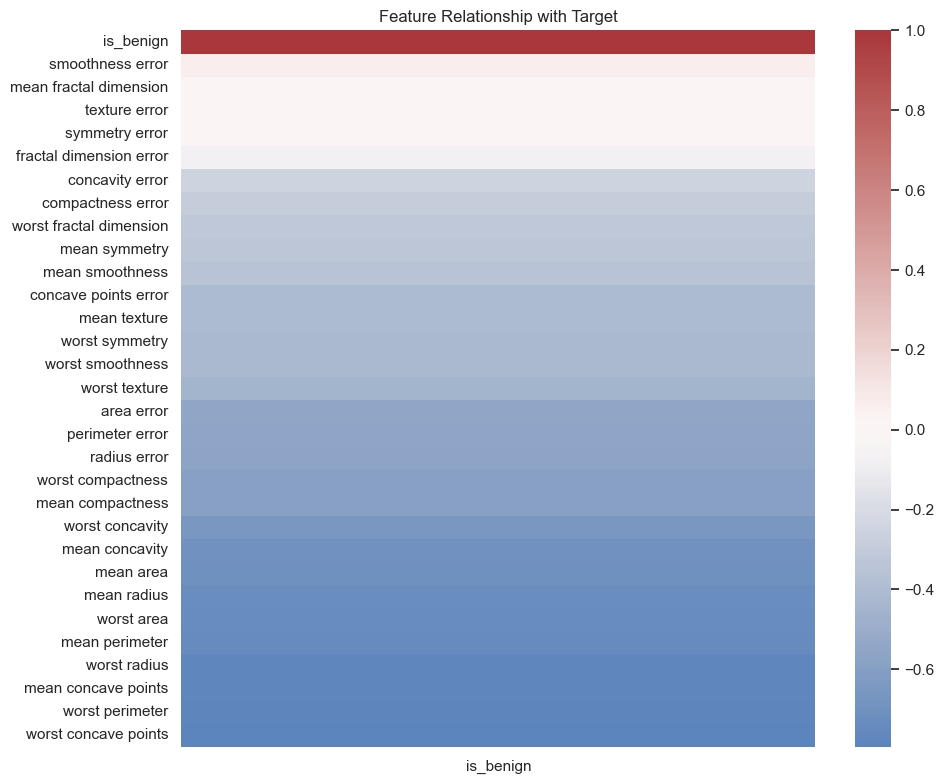

In [6]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[[TARGET_COLUMN]].sort_values(TARGET_COLUMN, ascending=False), cmap="vlag", center=0, annot=False)
plt.title("Feature Relationship with Target")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. What Is Underfitting?

Underfitting is what happens when the model is too simple for the world it is trying to understand.

It is the student who gives the same answer to every question because they learned a slogan instead of the concept. In ML terms, underfitting usually means high bias: the model has made assumptions so rigid that it cannot bend toward the real pattern.

Symptoms:

- poor training performance
- poor test performance
- small train/test gap
- model is not powerful enough to capture signal

We create an intentionally weak decision tree with `max_depth=1`. This is called a decision stump. It gets one split. One question. One chance to understand a complex medical dataset.

In [7]:
X_train, X_test, y_train, y_test = make_train_test_split(df)

models = {
    "Underfit Tree (depth=1)": underfit_tree(),
    "Balanced Tree (depth=4)": balanced_tree(),
    "Overfit Tree (unlimited)": overfit_tree(),
    "Regularized Logistic": regularized_logistic(C=0.5),
}

results = evaluate_many(models, X_train, X_test, y_train, y_test)
results.round(4)

,model,train_accuracy,test_accuracy,generalization_gap,precision,recall,f1,roc_auc
0,Underfit Tree (depth=1),0.9225,0.9231,-0.0005,0.9158,0.9667,0.9405,0.9079
1,Balanced Tree (depth=4),0.9624,0.9510,0.0114,0.9560,0.9667,0.9613,0.9636
2,Overfit Tree (unlimited),1.0000,0.9231,0.0769,0.9540,0.9222,0.9379,0.9234
3,Regularized Logistic,0.9883,0.9860,0.0022,0.9889,0.9889,0.9889,0.9977


## 9. What Is Overfitting?

Overfitting is the model becoming too impressed with the training data.

A deep decision tree can keep splitting until it creates tiny pockets of certainty. It can isolate unusual training examples and treat them as laws of nature. That feels powerful, but it is fragile.

Symptoms:

- excellent training performance
- weaker test performance
- large train/test gap
- model learned noise, accidents, and quirks

This is why high training accuracy can be dangerous. It may mean the model learned the problem. It may also mean the model memorized the rehearsal.

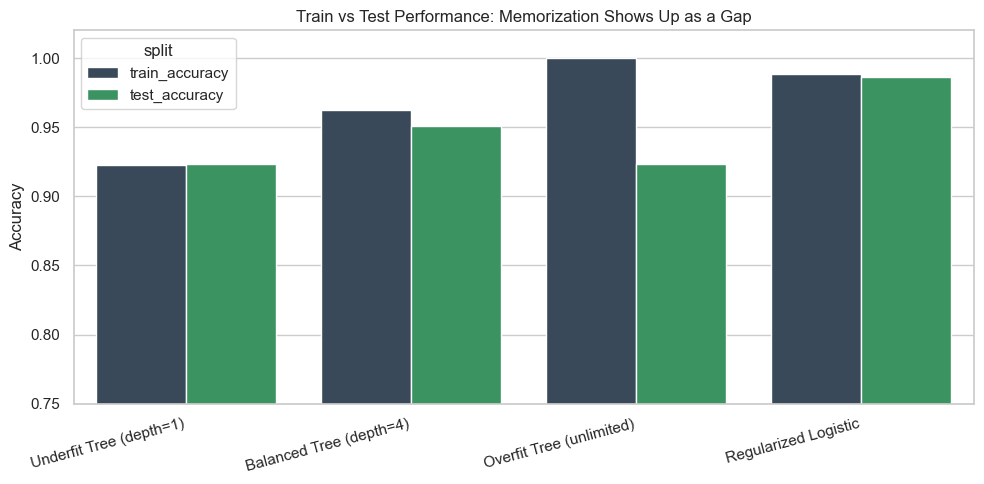

In [8]:
plot_train_test_bars(results, IMAGES_DIR / "train_vs_test.png")
plt.show()

## 10. The Sweet Spot - Generalization

A good model is not the one that worships the training data. It is the one that learns the reusable structure.

The balanced tree is allowed to discover interactions, but not allowed to split forever. Regularized logistic regression is allowed to use many features, but it is discouraged from assigning wildly large weights.

That is the sweet spot: enough flexibility to learn, enough restraint to generalize.

In [9]:
comparison = results[["model", "train_accuracy", "test_accuracy", "generalization_gap", "precision", "recall", "f1", "roc_auc"]]
comparison.sort_values("test_accuracy", ascending=False).round(4)

,model,train_accuracy,test_accuracy,generalization_gap,precision,recall,f1,roc_auc
3,Regularized Logistic,0.9883,0.9860,0.0022,0.9889,0.9889,0.9889,0.9977
1,Balanced Tree (depth=4),0.9624,0.9510,0.0114,0.9560,0.9667,0.9613,0.9636
0,Underfit Tree (depth=1),0.9225,0.9231,-0.0005,0.9158,0.9667,0.9405,0.9079
2,Overfit Tree (unlimited),1.0000,0.9231,0.0769,0.9540,0.9222,0.9379,0.9234


## 11. Bias vs Variance Explained Intuitively

Bias is the error of being too rigid.

A high-bias model walks into a complicated room and says, "I already know what shape this should be." It simplifies too aggressively. It misses detail. It underfits.

Variance is the error of being too reactive.

A high-variance model treats every small fluctuation as a message from the universe. It overreacts to the training data. It overfits.

The tradeoff is not a dry equation. It is the emotional center of model building:

- too much bias: the model refuses to listen
- too much variance: the model believes everything
- good generalization: the model listens carefully, then keeps only what seems durable

## 12. Visualizing Model Complexity

Now we increase decision tree depth one step at a time. Watch what happens.

At low depth, the model is too simple. As depth increases, it learns more. But after a point, training accuracy keeps climbing while test accuracy stops improving or becomes unstable. That split is the fingerprint of overfitting.

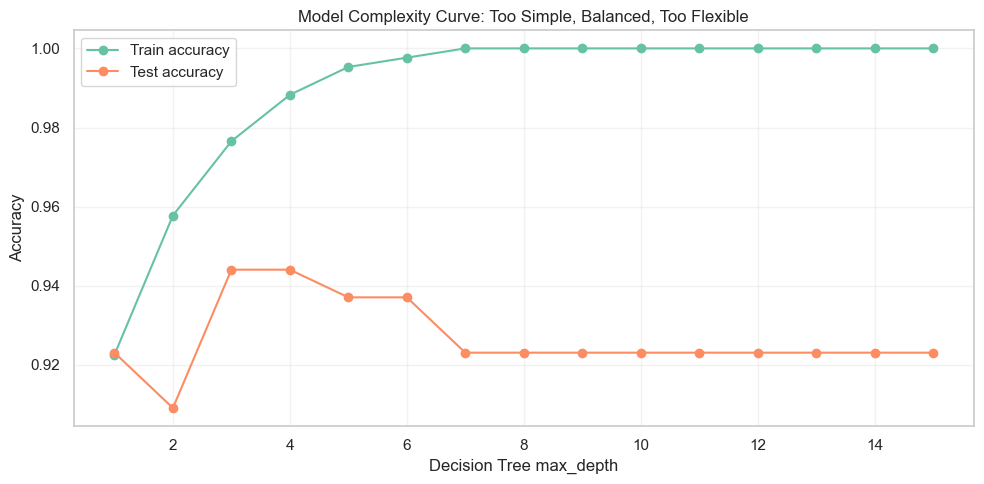

,max_depth,train_accuracy,test_accuracy
0,1,0.9225,0.9231
1,2,0.9577,0.9091
2,3,0.9765,0.9441
3,4,0.9883,0.9441
4,5,0.9953,0.9371


In [10]:
complexity_df = decision_tree_complexity_curve(X_train, X_test, y_train, y_test, depths=range(1, 16))
plot_complexity_curve(complexity_df, IMAGES_DIR / "model_complexity.png")
plt.show()
complexity_df.round(4).head()

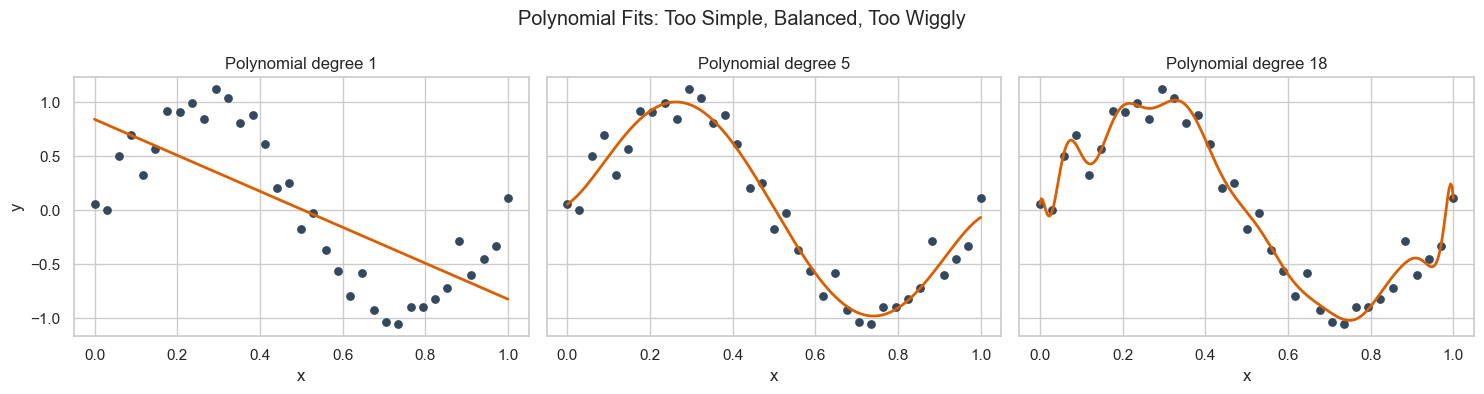

In [11]:
# A small synthetic regression scene makes memorization visually obvious.
rng = np.random.default_rng(42)
x = np.linspace(0, 1, 35)
y = np.sin(2 * np.pi * x) + rng.normal(0, 0.18, size=x.shape)
x_grid = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, degree in zip(axes, [1, 5, 18]):
    coefs = np.polyfit(x, y, deg=degree)
    y_grid = np.polyval(coefs, x_grid)
    ax.scatter(x, y, s=28, color="#34495e", label="training points")
    ax.plot(x_grid, y_grid, color="#d95f02", linewidth=2)
    ax.set_title(f"Polynomial degree {degree}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.suptitle("Polynomial Fits: Too Simple, Balanced, Too Wiggly")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "polynomial_fits.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Cross Validation Intuition

One train/test split is one version of reality.

If the split is lucky, the model may look stronger than it is. If the split is unlucky, it may look weaker than it is. Cross-validation rotates the validation role across different slices of the data, giving us a more stable estimate of generalization.

It is like asking: does this model work only on one doorway into the data, or does it keep working when we enter from different angles?

In [12]:
cv_models = {
    "Underfit Tree": underfit_tree(),
    "Balanced Tree": balanced_tree(),
    "Overfit Tree": overfit_tree(),
    "Regularized Logistic": regularized_logistic(C=0.5),
}
cv_results = cross_validation_table(cv_models, df.drop(columns=[TARGET_COLUMN]), df[TARGET_COLUMN], cv=5)
cv_results[["model", "cv_mean", "cv_std"]].round(4)

,model,cv_mean,cv_std
0,Underfit Tree,0.8998,0.0162
1,Balanced Tree,0.9385,0.0193
2,Overfit Tree,0.9173,0.0242
3,Regularized Logistic,0.9807,0.0065


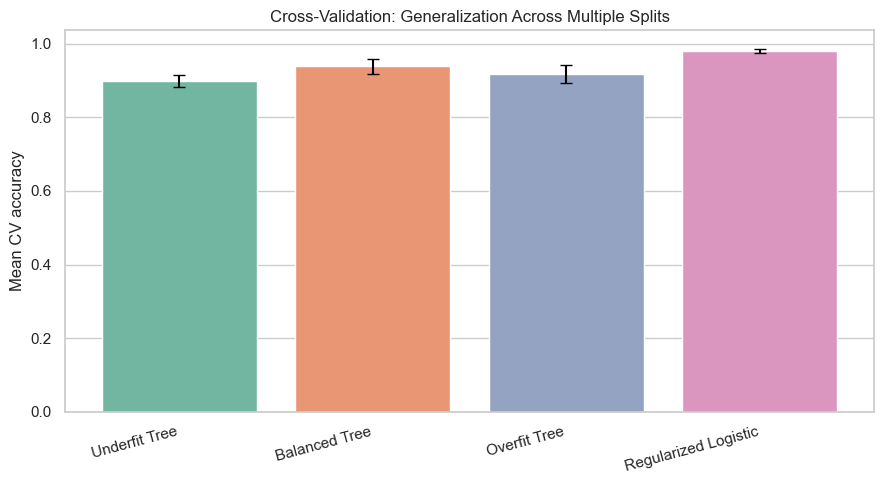

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(data=cv_results, x="model", y="cv_mean", palette="Set2")
plt.errorbar(x=np.arange(len(cv_results)), y=cv_results["cv_mean"], yerr=cv_results["cv_std"], fmt="none", color="black", capsize=4)
plt.title("Cross-Validation: Generalization Across Multiple Splits")
plt.xlabel("")
plt.ylabel("Mean CV accuracy")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "cross_validation_scores.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Regularization - Controlling Complexity

Regularization is a model-building form of humility.

It tells the model: use the patterns, but do not become too dramatic about them.

For logistic regression, smaller `C` means stronger regularization. The model is pushed toward smaller coefficients. It can still learn, but it is discouraged from building a fragile explanation around any one feature.

For trees, regularization often looks like:

- limiting `max_depth`
- increasing `min_samples_leaf`
- pruning weak branches
- requiring stronger evidence before a split

Regularization does not make models weaker. It makes them less gullible.

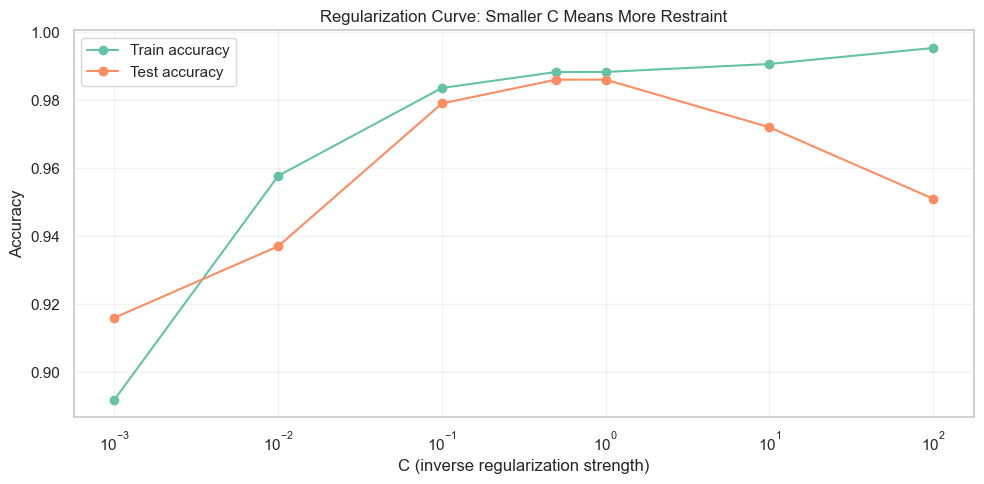

,C,train_accuracy,test_accuracy
0,0.001,0.8920,0.9161
1,0.010,0.9577,0.9371
2,0.100,0.9836,0.9790
3,0.500,0.9883,0.9860
4,1.000,0.9883,0.9860
5,10.000,0.9906,0.9720
6,100.000,0.9953,0.9510


In [14]:
c_values = [0.001, 0.01, 0.1, 0.5, 1, 10, 100]
reg_rows = []
for c in c_values:
    model = regularized_logistic(C=c)
    model.fit(X_train, y_train)
    reg_rows.append({
        "C": c,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
    })
reg_df = pd.DataFrame(reg_rows)

plt.figure(figsize=(10, 5))
plt.semilogx(reg_df["C"], reg_df["train_accuracy"], marker="o", label="Train accuracy")
plt.semilogx(reg_df["C"], reg_df["test_accuracy"], marker="o", label="Test accuracy")
plt.title("Regularization Curve: Smaller C Means More Restraint")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "regularization_curve.png", dpi=160, bbox_inches="tight")
plt.show()
reg_df.round(4)

## 15. Learning Curves

Learning curves show how performance changes as the model gets more training examples.

They help diagnose model failure:

- underfitting: train and validation scores are both low and close together
- overfitting: training score is high, validation score is lower, and the gap is large
- data hunger: validation improves steadily as more data arrives

Learning curves are not just plots. They are model debugging conversations.

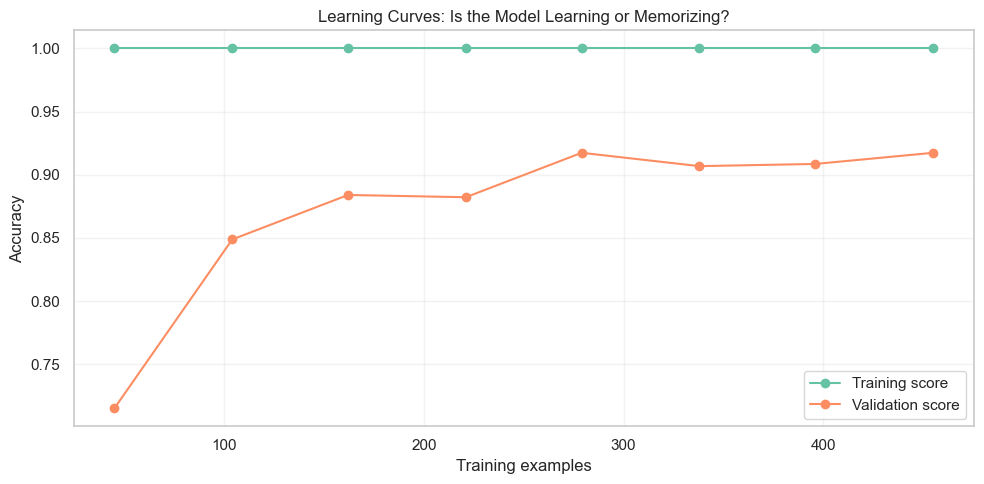

In [15]:
plot_learning_curves(overfit_tree(), df.drop(columns=[TARGET_COLUMN]), df[TARGET_COLUMN], IMAGES_DIR / "learning_curves.png", cv=5)
plt.show()

## 16. Practical ML Debugging

When a real ML engineer sees poor model performance, they do not simply ask, "Which algorithm should I try next?"

They ask diagnostic questions:

- Is training performance also bad? If yes, suspect underfitting, weak features, excessive regularization, or the wrong model family.
- Is training performance excellent but test performance weak? If yes, suspect overfitting, leakage, too much complexity, or unstable splits.
- Is validation performance suspiciously high? If yes, check for data leakage.
- Does performance vary wildly across folds? If yes, the model may be high variance or the dataset may be too small.
- Do learning curves improve with more data? If yes, data collection may help.
- Does regularization improve test performance while lowering training performance? If yes, the original model was probably too flexible.

The workflow is less like pressing buttons and more like listening to symptoms.

## 17. Final Comparison

The story becomes clear when we place the models side by side.

The underfit model has too little capacity. The overfit model has too much freedom. The best models are the ones that capture useful signal without trusting every training detail.

In [16]:
final_table = comparison.sort_values("test_accuracy", ascending=False).round(4)
final_table

,model,train_accuracy,test_accuracy,generalization_gap,precision,recall,f1,roc_auc
3,Regularized Logistic,0.9883,0.9860,0.0022,0.9889,0.9889,0.9889,0.9977
1,Balanced Tree (depth=4),0.9624,0.9510,0.0114,0.9560,0.9667,0.9613,0.9636
0,Underfit Tree (depth=1),0.9225,0.9231,-0.0005,0.9158,0.9667,0.9405,0.9079
2,Overfit Tree (unlimited),1.0000,0.9231,0.0769,0.9540,0.9222,0.9379,0.9234


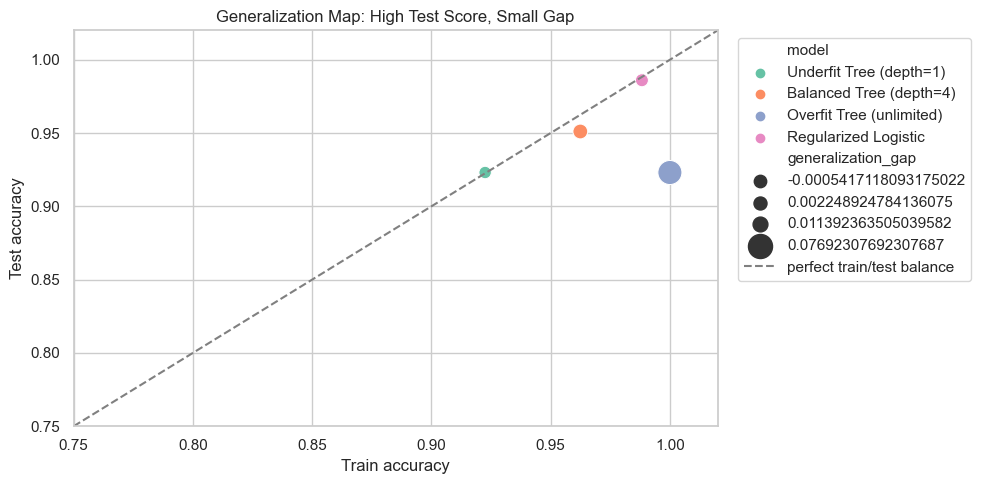

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=results, x="train_accuracy", y="test_accuracy", size="generalization_gap", hue="model", sizes=(80, 300))
plt.plot([0.75, 1.02], [0.75, 1.02], linestyle="--", color="gray", label="perfect train/test balance")
plt.title("Generalization Map: High Test Score, Small Gap")
plt.xlabel("Train accuracy")
plt.ylabel("Test accuracy")
plt.xlim(0.75, 1.02)
plt.ylim(0.75, 1.02)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "generalization_map.png", dpi=160, bbox_inches="tight")
plt.show()

## 18. Key Learnings

- Overfitting is memorization disguised as intelligence.
- Underfitting is oversimplification disguised as stability.
- Training accuracy alone is not evidence of a useful model.
- The train/test gap is one of the fastest ways to detect memorization.
- Cross-validation makes our estimate of generalization less dependent on one split.
- Regularization controls complexity by adding restraint.
- Learning curves help diagnose whether we need more data, better features, more flexibility, or more regularization.
- Real ML engineering is the art of asking why a model failed, not just whether it failed.

## 19. Final Takeaway

Machine learning does not reward the model that remembers the most.

It rewards the model that learns what still matters when the scene changes.

A model can memorize. A model can generalize. The difference is where real machine learning begins.

## 20. Interview Questions

For detailed interview preparation, see:

`overfitting-vs-underfitting/interview_questions.md`

The companion article turns these questions into practical ML engineering explanations.